# Mean-Field approximations

Systems of interacting degrees of freedoms can rarely be treated exactly. Instead, approximation techniques have been developed to study and understand the behaviors of such systems.
The "standard" systems for which many of these techniques were developed are systems of interacting magnetic spins $\sigma_i\in [-1,1]$ that can be in one of two possible states.
The energy of such a system is written as 
$$
H(\mathbf{\sigma}) = -\sum_i h_i \sigma_i - \sum_{i<j} J_{ij} \sigma_i\sigma_j
$$
where $h_i$ is a local "magnetic field" acting on spin $i$ and $J_{ij}$ parameterizes the interaction between spins $i$ and $j$. In a system in finite dimensions, $J_{ij}$ will only be non-zero for neighboring spins. This model is called the Ising model of magnetism. It can be solved exactly in one (easy) and two dimensions (hard).

The equilibrium (or maximum entropy) properties of such a system are governed by the partition sum
$$
Z = \sum_{\mathbf{\sigma}} e^{-H(\mathbf{\sigma})/kT} \, , 
$$
which determines the probability of microstates as $p = Z^{-1}e^{-H(\mathbf{\sigma})/kT}$, the free energy as $F = -kT \log Z$, and expectation values as derivatives of the free energy (or $\log Z$). 
Specifically, 
$$
F = \langle H \rangle - T S = Z^{-1}\sum_{\mathbf{\sigma}} H(\mathbf{\sigma})e^{-H(\mathbf{\sigma})/kT} + kT Z^{-1}\sum_{\mathbf{\sigma}} e^{-H(\mathbf{\sigma})/kT} (-H(\mathbf{\sigma})/kT - \log Z) = -kT \log Z
$$

The challenge in calculating $Z$ stems from the exponentially many terms that need summing. In constrast to one dimensional or non-interacting systems, for complex problems in more than one dimension these sums can typically not be broken into products. 

## Heuristic mean-field approach
Consider the spin Hamiltonian above. The energy difference between the two states of one spin $\sigma_i$ (the remainder kept constant) is given by 
$$
\Delta H_i = -2h_i - 2\sum_{j\in \partial i} J_{ij}\sigma_j
$$
where $\partial i$ is the set of spins interacting with $i$. 
We can now consider this spin $i$ as an isolated spin in an effective field 
$$
h_{eff} = h_i + \sum_{j\in \partial i} J_{ij}\sigma_j
$$
and calculate its partition sum as
$$
Z_0 = e^{h_{eff}/kT} + e^{-h_{eff}/kT} = 2\cosh(h_{eff}/kT)
$$
with an average magnetization
$$
\langle \sigma_i \rangle = -kT \partial_{h_i} \log Z_0 = \tanh(h_{eff}/kT))
$$
We have thus obtained an expression for the average of $\sigma_i$. In a homogeneous system with $J_{ij}=J$ and $h_i=h$, we might expect that the magnetization is homogenous as well and that we could replace $\sigma_j$ in the expression for $h_{eff}$ with $\langle \sigma \rangle$, obtaining the relation
$$
\langle \sigma \rangle = \tanh\left(\frac{h + zJ\langle \sigma \rangle}{kT}\right)\, ,
$$
where $z$ is the number of lattice neighbors of site $i$.
This equation allows for different solutions depending on the values of $J/kT$ and $h/kT$. Setting $kT=1$ and introducing the magnetization $m = \langle \sigma \rangle$, we find the simplified mean-field consistency condition:
$$
m = \tanh\left(h + zJm\right)
$$
This transcendental equation does not have an explicit solution for $m$. 

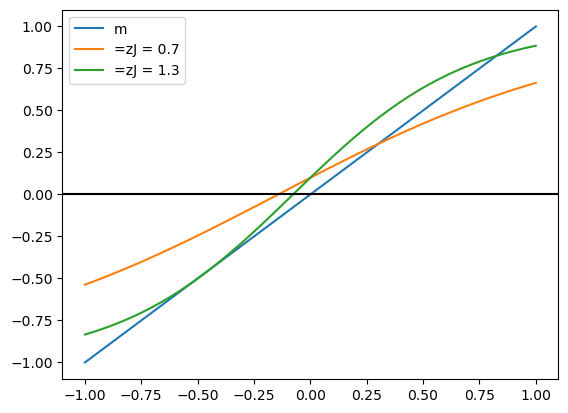

In [3]:
import numpy as np
import matplotlib.pyplot as plt

m = np.linspace(-1,1,101)
plt.plot(m,m, label='m')
h=0.1
for zJ in [0.7, 1.3]:
    plt.plot(m, np.tanh(h+zJ*m), label=f'=zJ = {zJ}')
plt.axhline(0, c='k')
plt.legend()


For $h=0$, there always is a trival solution with $m=0$. If $zJ/kT$ is larger than 1, there are two symmetric additional solutions with finite magnetization. 

A thermodynamically stable state has to minimize the free energy which, assuming the orientiation of each spin is independent of all others, is given by 
$$
\frac{F}{N}\approx -h m - zJ m^2 + \frac{kT}{2} \left[(1-m)\log(1-m) + (1+m)\log(1+m)\right]
$$
where we have used that $p=(1+m)/2$ and dropped a constant. 

The term "mean field" comes from the study of magnets and refers to situations where the effect of many neighboring spins in a magnet can be replaced by one effective magnetic field -- an approach that ignores correlations between components of the system.

## Mean-field approximation and the variational principle

The theoretical under-pinning of mean field models is provided by the so called variational principle and the concavity of the exponential function. The latter implies that average of an exponential is larger than the exponential of the average
$$
\langle e^{f} \rangle = e^{\langle f \rangle}\langle e^{f- \langle f \rangle} \rangle \geq e^{\langle f \rangle}\langle 1 + f- \langle f \rangle \rangle= e^{\langle f \rangle}
$$
Now consider such a simple "trial" $H_0$ whose partition sum can be calculated exactly as $Z_0 = \sum_{\mathbf{\sigma}} e^{-H_0(\mathbf{\sigma})/kT}$. We can then express the full partition sum as
$$
Z = \sum_{\mathbf{\sigma}} e^{-H(\mathbf{\sigma})/kT} = Z_0 \sum_{\mathbf{\sigma}} Z_0^{-1} e^{-H_0(\mathbf{\sigma})/kT} e^{-(H(\mathbf{\sigma})-H_0(\mathbf{\sigma}))/kT} = Z_0 \langle e^{-(H(\mathbf{\sigma})-H_0(\mathbf{\sigma}))/kT}\rangle_0
$$
The notation $\langle \cdots \rangle_0$ indicates the average over the ensemble defined by the trial Hamiltonian.  

In the next step, we now replace the average of the exponential with an exponential of the average to obtain
$$
Z  = Z_0 \langle e^{-(H(\mathbf{\sigma})-H_0(\mathbf{\sigma}))/kT}\rangle_0 \geq Z_0  e^{-\langle H(\mathbf{\sigma})-H_0(\mathbf{\sigma})\rangle_0/kT}
$$
The trial hamiltonian $H_0$ that maximizes the right hand side will be the best approximation of the partition sum and one typically uses a form of $H_0$ that (i) is simple to calculate, and (ii) that has adjustable parameters with respect to which the solution can be optimized. 

Going back to the examples of interacting Ising spins, the most obvious trial Hamiltonian is 
$$
H_0(\mathbf{\sigma}) = -\lambda \sum_i \sigma_i
$$
where each spin has a magnetization 
$$
m = \tanh(\lambda/kT)
$$
which is monotonically related to $\lambda$. 
Taking the logarithm of $Z_0  e^{-\langle H(\mathbf{\sigma})-H_0(\mathbf{\sigma})\rangle_0/kT}$ we obtain a an upper bound on the free energy that we now want to minimize
$$
F\leq F_0 = \langle H\rangle_0  - TS_0 =   -Nh m - \frac{NzJ}{2} m^2  + \frac{kTN}{2} \left[(1-m)\log(1-m) + (1+m)\log(1+m)\right]
$$
Differentiating with respect to $m$, we have
$$
0 =   -h - zJ m  + \frac{kT}{2} \left[-\log(1-m) + \log(1+m)\right] = -h - zJ m  - \frac{kT}{2}\log\frac{1-m}{1+m} = -h - zJ m  - \tanh^{-1}(m)
$$
and recover the same condition as via our argument above. In addition, we now have a principled way of picking a solution if there are several: the one that minimizes the free energy is the physically relevant one. 

### Mean field solution of the Ising model
Consider the case of $h=0$ and define $T_c = Jz/k$. The mean-field condition for the magnetisation then reads
$$
m = \tanh(m T_c/T)
$$
which allows only $m=0$ for $T>T_c$ but has an $m>0$ solution for $T<T_c$. The mean field therefore suggests a phase transition, which indeed exists in dimensions larger than or equal to two. 

For $T<T_c$, the system undergoes spontaneous symmetry breaking where one of two solution $m=\pm |m|$ is picked globally.





In general, mean field approximations involve ignoring some correlations between components of the system that make evaluation intractable. In the simple example, interactions between spins are replaced by interaction with the average field generate by lots of spins, thereby ignoring correlations between specific spins. Mean field models tend to by good approximation when there are a many weak interactions, which is typically true in higher dimensions. That is why mean-field often works well in the three dimensions or higher, but is problematic in one or two dimensions. 


# Poisson-Boltzmann distributions

A classic mean field theory relevant in biology describes the distribution of ions in the vicinity of charged surfaces. 

![charged_DNA](figures/PBOC_charged_DNA.jpg)

The problem we have is to calculate the distribution of charged ions $c(\vec{x})$, which is determined by the electrical potential $V(\vec{x})$, which itself is a product of the charge distribution.
The physical equations governing this problem are (i) the Poisson equation
$$
\frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} +\frac{\partial^2 V}{\partial z^2} = -\frac{ze}{\epsilon}c(\vec{x})
$$
where $\epsilon$ is the dielectric constant or permittivity, $z$ is the valency of the ions, and $e$ is the elementary charge. The second ingredient is the Boltzman distribution describing the probability to find a charged particle at a particular position in an external electric field
$$
c(\vec{x}) = c_{\infty}e^{-\frac{zeV(\vec{x})}{kT}}
$$
where $ez$ is the charge and $c_{\infty}$ is the concentration at infinity. 

This problem is solved using a 'mean-field' idea: Consider each charge in an effective field generated by a large number of charges such that correlation between specific charges can be ignored. In that case, we can combine the two equations into one that can be solved for the charge density. 


For concreteness, consider a charged surface and the charge distribution perpendicular to it. 
![charged_surface](figures/PBOC_charged_surface.jpg)

If we look for solutions that only vary along the $x$ coordinate and consider postive and negatively charged densities $c_{-}$ and $c_{+}$ of valency $z$, we can combine the Poisson equation with the Boltzmann distribution to obtain
$$
\frac{\partial^2 V(x)}{\partial x^2} = -\frac{z e c_{\infty} \left(e^{-\frac{ezV(x)}{kT}}-e^{\frac{ezV(x)}{kT}}\right)}{\epsilon}
$$
To make progress, one typically assumes that $\frac{ezV(x)}{kT}\ll 1$ and expands the Boltzmann factors to obtain
$$
\frac{\partial^2 V(x)}{\partial x^2} = -\frac{2c_{\infty} e^2z^2}{\epsilon kT}V(x)
$$
from which we immediately see that the charge density in the vicinity of a charged surface decays exponentially with a length scale $l=\sqrt{\epsilon kT/2c_{\infty}}/(ez)$. At distances larger than that, the effect of charged structures are screen by mobile ions. 

For typical concentrations of monovalent ions ($200mM$) the screening length is on the order of a nanometer. 


# Polymers

The simplest models of flexible polymers is just a random walk in space. One such model is known as the freely jointed chain model where the next step is always a step of length $b$ in a random direction. 




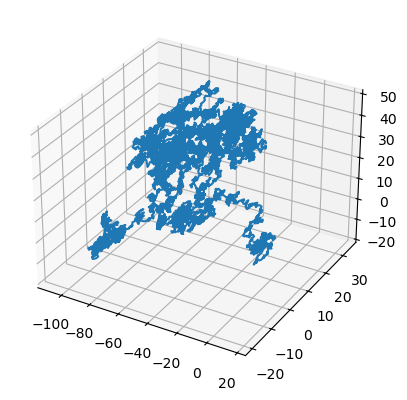

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# return a vector on the sphere with angles theta (polar) and phi (azimuth)
# see https://en.wikipedia.org/wiki/Spherical_coordinate_system
def unit_vector(phi, theta):
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return (x,y,z)    

# pick a random vector such that each direction is equally likely
def random_unit_vector():
    phi = np.random.uniform(0,np.pi*2)  # any azimuth is equally likely
    costheta = np.random.uniform(-1,1)  # theta around pi/2 are more likely than 0 or pi
    theta = np.arccos(costheta)
    return unit_vector(phi, theta)

def freely_jointed_chain(N, b):
    # initial position
    positions = [ np.array([0,0,0]) ]
    for n in range(N):
        # increment position 
        positions.append(positions[-1] + b*random_unit_vector())
    return np.array(positions)

b = 1
N = 10000
positions = freely_jointed_chain(N,b)

# plot the trajectory
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(positions[:,0], positions[:,1], positions[:,2])

Such a model has a number of simple properties, for example the end-to-end distance or the radius of gyration scale as $b\sqrt{N}$, which are at least qualitatively are borne out in observations. But a random walk evidently is not a realistic model since it does not prevent a point in space to be occupied multiple times by different monomers of the polymer. Ignoring such excluded volume effects is of course completely wrong in one dimension where a real polymer can never go back. In two dimension, excluded volume effects are still substantial, but in three dimensions they can be captured well be a mean-field like argument. 

## Return probabilities of random walks

The probability that a random walk returns in the vicinity of its starting point after time $t$ depends strongly on the dimension of space. This is most readily seen by by just considering the density of the Gaussian solution to the diffusion equation:
$$
P(\vec{x}|t, 0) = \frac{1}{(4\pi Dt)^{d/2}} e^{-\frac{|\vec{x}|^2}{4Dt}}
$$
The density at $\vec{x}=0$ decays with time as $t^{-d/2}$. Integrating this over time gives you a rough appreciation of how often a random walk comes back to the origin. This clearly diverges for $d=1$, increases logarithmically for $d=2$ and is finite for any $d>2$. This of argument of course ignores the fact that the location of a random walker is strongly correlated in time. To make this argument more precise, you'd have to calculate distribution of "first return" to the origin (related to famous Gambler's ruin problems). This is quite straighforward in one dimension and will be provided as an exercise. 


## Overlap probabilities

Consider a polymer with $N$ monomers each of length $b$. The volume occupied by a monomer will be roughly $b^d$, while the radius of an ideal random polymer configuration will be $\sim bN^{1/2}$. The ratio of the two associated volumes, i.e. the volume fraction occupied by the polymer, is then
$$
\phi^* \sim \frac{b^dN}{(bN^{1/2})^d} = N^{1-d/2}
$$
confirming our intuition that overlap is a strong constraint in $d=2$ and a perturbation in $d=3$ or higher. 

Furthermore, we can ask how many monomers touch other monomers in the entire chain (does any of the $N$ monomers touch another?) by multplying $\phi^*$ by $N$.
This suggests that in $d>4$ the typical polymer chain is unaffected by excluded volume interactions, but for $d=3$, we still expect on the order of $N^{-1/2}$ interactions between monomers of the chain. 



### Entropic contributions of excluded volume interactions and swelling

So far our arguments have been as follows: Let's assume a ideal polymer conformation without constraints. How many inconsistencies do we expect? These excluded volume interactions will results in polymer conformations to be more extended, but a priori it is unclear whether this will merely affect a prefactor or change the scaling behavior and structure away from $R\sim b N^{1/2}$. 

The main two forces at play in this case are both of entropic nature
 - excluded volume reduces entropy through a reduction of the number of places a monomer can be
 - swelling (distribution of the polymer over larger volumes) reduces the conformational entropy

Flory balanced these two contributions using mean-field type arguments considering a model where the polymer is occupying a sphere of radius $R$ and then optimizing a free energy with respect this radius.

#### Excluded volume
The excluded volume effect reduces the volume by a factor $1 - c b^3N/R^3$ per monomer ($c$ is a constant) and this increases the free energy by 
$$
F_{ex} = kT \frac{cb^3N^2}{R^3}
$$
(The free energy difference to do a fractional reduction $\epsilon$ in available volume is $-kT N\log(1-\epsilon)\approx kTN\epsilon$.)

#### Swelling
Increasing the end-to-end distance (and analogously the distance between any far away monomers) reduces the entropy of the conformation and the polymer resists such swelling with an entropic force ([see here for a simple treatment](https://github.com/neherlab/PoL1-course-materials/blob/main/notebooks/lecture07c_PullingOnPolymers.ipynb)). Integrating this force from $0$ to $R$ yields
$$
F_{sw} = kT \frac{3kT}{2Nb^2}R^2
$$



### Flory scaling exponent
Combining these two terms gives a contribution 
$$
F \approx kT \left(\frac{cb^3N^2}{R^3}  + \frac{3}{2Nb^2}R^2\right)
$$
where we can differentiate with respoect to $R$ and determine its minimum:
$$
\frac{\partial F}{\partial R} \approx kT \left(-\frac{3cb^3N^2}{R^4}  + \frac{3}{Nb^2}R\right) =0
$$
and thus
$$
R^5 = cb^5N^3
$$
or $R\sim N^{3/5}$. For general dimension $d$, this relation becomes $R\sim N^{3/(d+2)}$. 

More sophisticated theories and numerical approaches suggest that in 3 dimensions the exponent should be $\nu \approx 0.588$ which is pretty close to $3/5$. In two dimensions, the result $3/4$ is exact (these problems can be solved exactly and [even rigorously in $d=2$](https://en.wikipedia.org/wiki/Schramm%E2%80%93Loewner_evolution)). For $d=4$, we recover the results of non-interacting random walks, while for higher dimensions the balance that we have set up is not the relevant balance. Excluded volume interactions vanish in the scaling limit of $d>4$.


